<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Missing_Indicator_Random_Sample_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Sample Imputation

- Fill numbers randomly by choosing from the data given
- It can be applied to both numerical and categorical columns

Benifit:
- Easy to apply, cannot be applied using sklearn but given in pandas
- variance/distribution intact remains same when dealing with linear algorithms its important not for decision tree algos

Disadvantage:
- covariance disturbs due to randomness
- memory heavy, as we need to store the original training set to extract values from and replace NA in coming observation

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv', usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
from numpy.random.mtrand import RandomState
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [8]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


In [9]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed' ][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values
# Find all missing ages in Age_imputed and replace them with randomly selected real ages from the original Age column

/tmp/ipykernel_7383/3016688561.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_7383/3016688561.

In [10]:
X_train.tail()

,Age,Fare,Age_imputed
534,30.0,8.6625,30.0
584,NaN,8.7125,30.0
493,71.0,49.5042,71.0
527,NaN,221.7792,47.0
168,NaN,25.9250,33.0


/tmp/ipykernel_7383/199461764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'], label='original', hist=False)
/tmp/ipykernel_7383/199461764.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'], label='Imputed', hist=False)


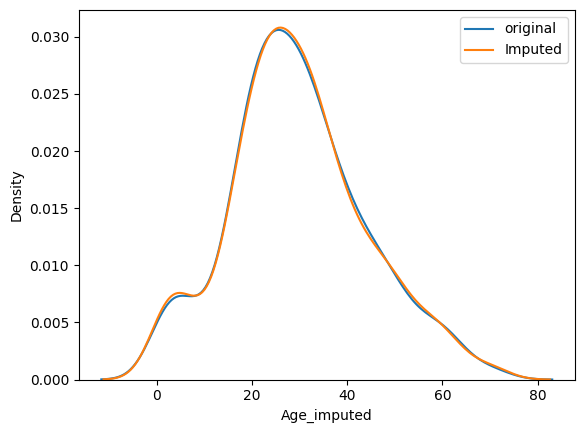

In [11]:
sns.distplot(X_train['Age'], label='original', hist=False)
sns.distplot(X_train['Age_imputed'], label='Imputed', hist=False)

plt.legend()
plt.show()

In [12]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train[ 'Age_imputed' ].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  207.3710621515431


In [13]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,67.912450
Age,71.512440,204.349513,204.349513
Age_imputed,67.912450,204.349513,207.371062


<Axes: >

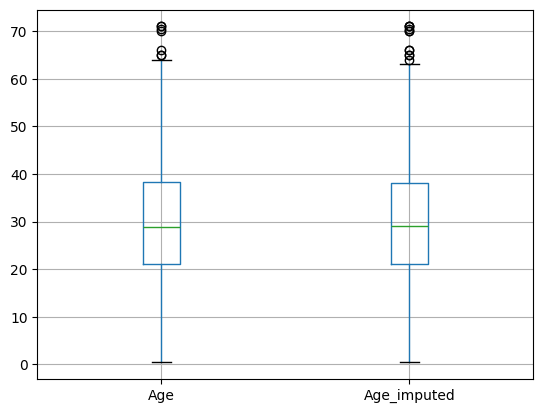

In [14]:
X_train[['Age', 'Age_imputed']].boxplot()

In [15]:
# in production ensure if the Fare is same we generate the same random value for the missing values of the Age
# sample_value = X_train['Age'].dropna().sample(1,random_state=int(observation['Fare'])) # observation here is what the fare given to us in production

In [16]:
data = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/house-train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [17]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [18]:
data.isnull().mean() *100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [19]:
X = data
y = data['SalePrice']

In [20]:
X_train,X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [21]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [22]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1395,Gd,TA,281213,TA,Gd
329,NaN,Fa,78000,Fa,NaN
855,NaN,TA,127000,TA,NaN
455,TA,TA,175500,TA,TA
129,NaN,TA,150000,TA,NaN


In [23]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_7383/1278872522.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tm

In [24]:
temp = pd.concat([
    X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()), # Calculate original category percentages ignoring missing values.
    X_train['GarageQual_imputed'].value_counts() / len(X_train) # Calculate category percentages after imputation.
], axis=1)
# axis=0 → vertical
# axis=1 → horizontal
temp.columns = ['original', 'imputed']

In [25]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.036815
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [26]:
temp = pd.concat([
    X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()), # Calculate original category percentages ignoring missing values.
    X_train['FireplaceQu_imputed'].value_counts() / len(X_train) # Calculate category percentages after imputation.
], axis=1)
# axis=0 → vertical
# axis=1 → horizontal
temp.columns = ['original', 'imputed']

In [27]:
temp

,original,imputed
Gd,0.494272,0.494007
TA,0.412439,0.412671
Fa,0.040917,0.040240
Po,0.027823,0.027397
Ex,0.024550,0.025685


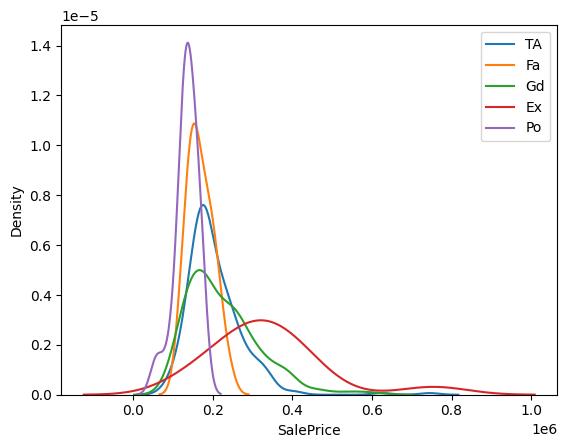

In [28]:
for category in X_train['FireplaceQu'].dropna().unique():
  sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category)
plt.legend()
plt.show()

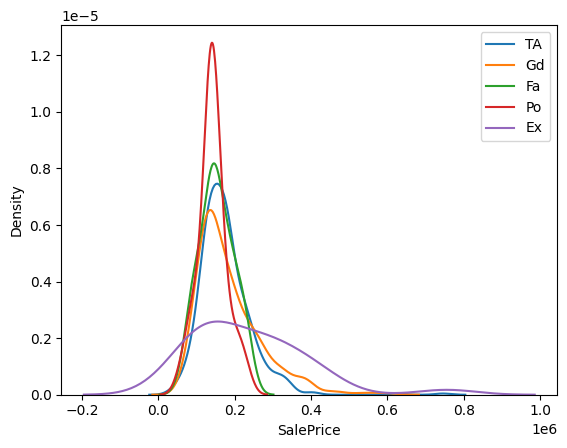

In [29]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
  sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category)
plt.legend()
plt.show()

# distribution changed

# Missing Indicator

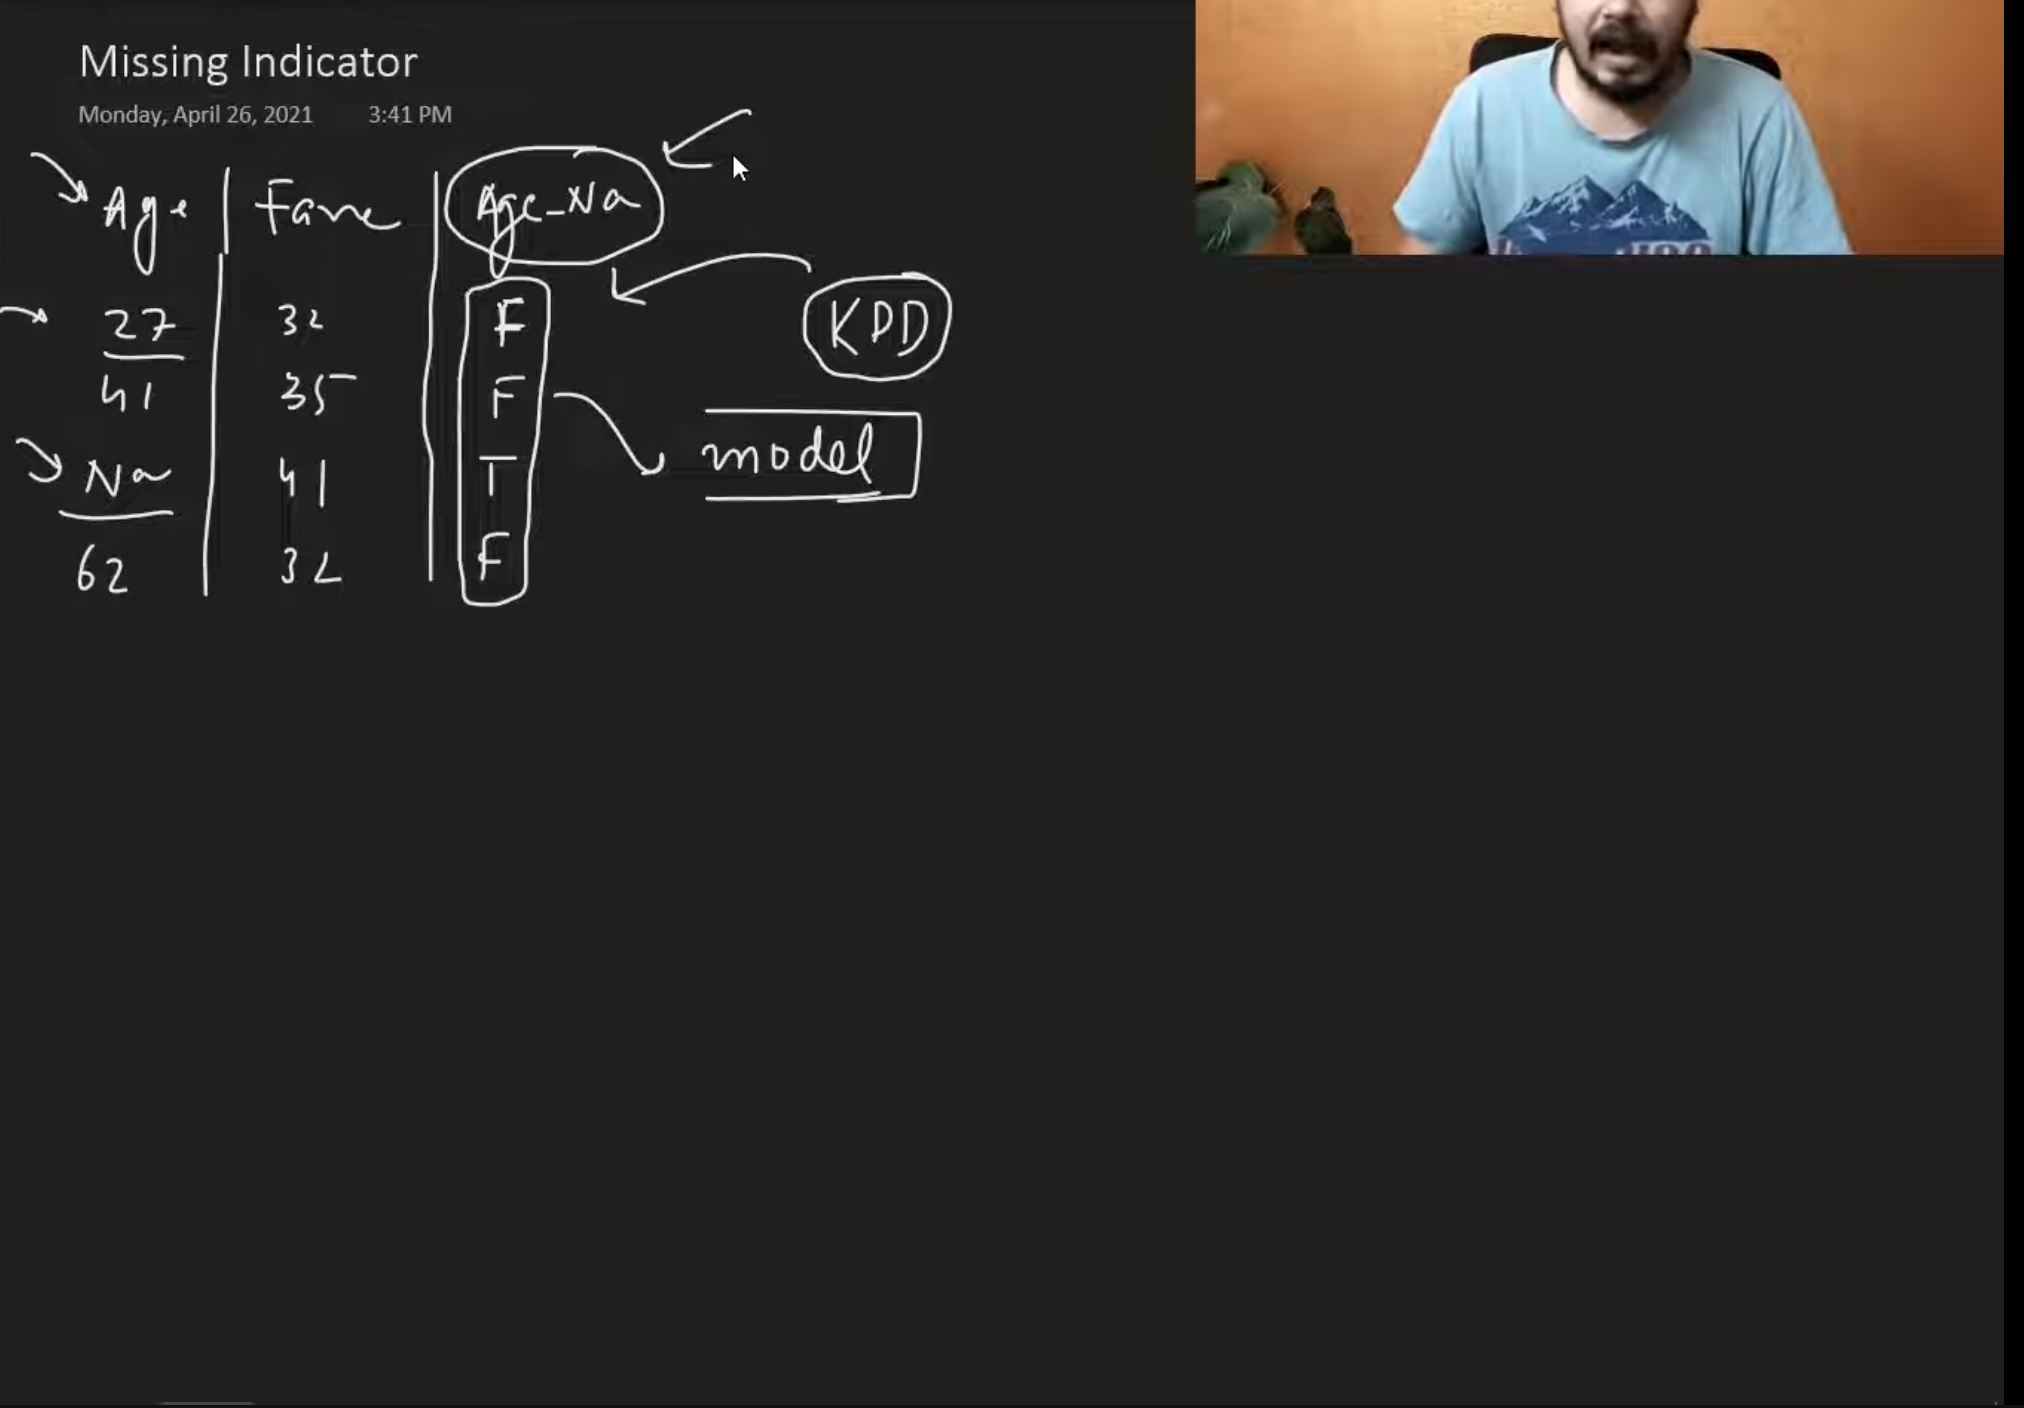

In [30]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv', usecols=['Age','Fare','Survived'])

In [31]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [32]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=2)

In [34]:
from sklearn.impute import SimpleImputer

In [35]:
si = SimpleImputer()

In [36]:
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train_trf, y_train)

y_pred = clf.predict(X_test_trf)

In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6535764375876578

In [39]:
from sklearn.impute import MissingIndicator
mi = MissingIndicator()
mi.fit(X_train)

MissingIndicator()

In [40]:
mi.features_ #array([0]) means first col has missing values

array([0])

In [41]:
X_train_missing = mi.transform(X_train)
X_test_missing = mi.transform(X_test)

In [42]:
X_train_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [

In [43]:
X_train['Age_NA'] = X_train_missing

In [44]:
X_test['Age_NA'] = X_test_missing

In [45]:
X_train

,Age,Fare,Age_NA
657,32.0,15.5000,False
122,32.5,30.0708,False
750,4.0,23.0000,False
841,16.0,10.5000,False
361,29.0,27.7208,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [46]:
si = SimpleImputer()

In [47]:
X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train_trf2, y_train)

y_pred = clf.predict(X_test_trf2)

In [49]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6563814866760168

In [50]:
si = SimpleImputer(add_indicator=True) # shortcut

In [51]:
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [52]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train_trf, y_train)

y_pred = clf.predict(X_test_trf)

In [53]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6549789621318373

# Automatic Select

Automatically select value for imputation

**Grid search CV**

In [54]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv'
)

df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [55]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [56]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [57]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [58]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
30,1,male,40.0,0,0,27.7208,C
10,3,female,4.0,1,1,16.7000,S
873,3,male,47.0,0,0,9.0000,S
182,3,male,9.0,4,2,31.3875,S
876,3,male,20.0,0,0,9.8458,S


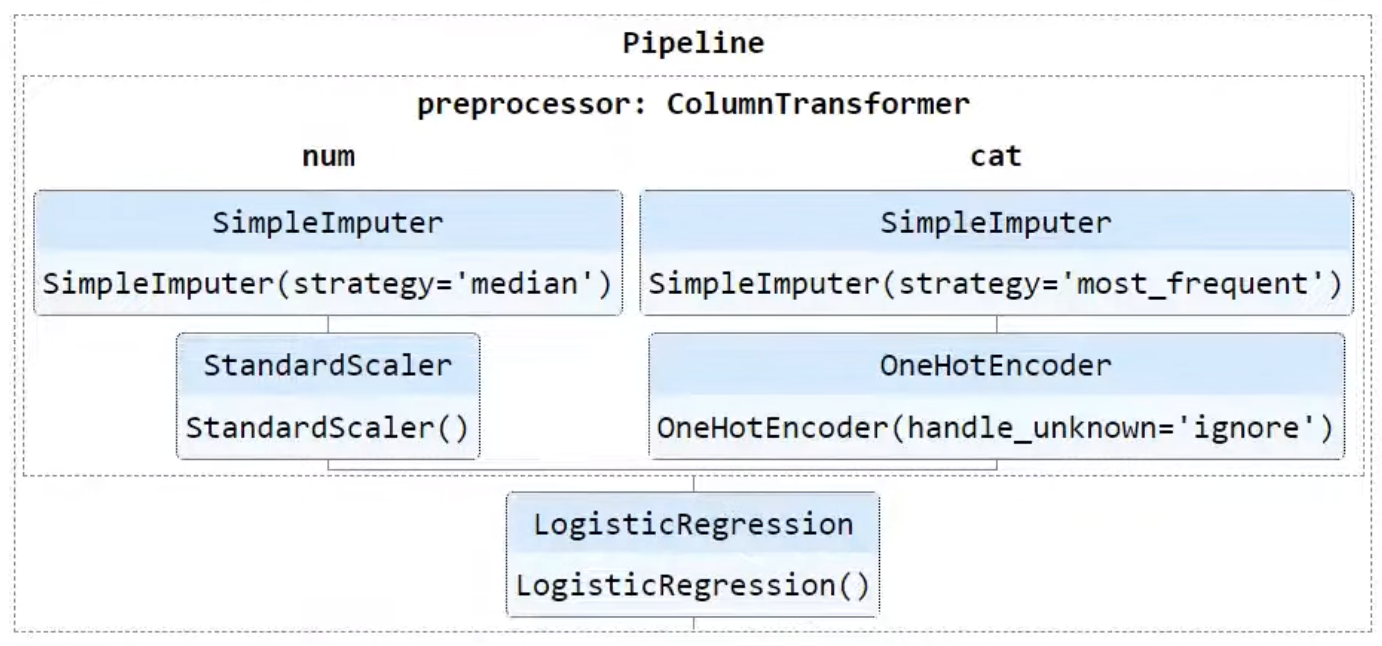

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numerical_features = ['Age', 'Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Embarked', 'Sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [61]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [62]:
from sklearn import set_config

set_config(display='diagram')
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'Sex'])])),
                ('classifier', LogisticRegression())])

In [68]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],

    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],

    'preprocessor__cat__imputer__fill_value': ['Missing'],

    'classifier__C': [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf, param_grid, cv =10)


In [72]:
grid_search.fit(X_train, y_train)

print('Best params:')
print(grid_search.best_params_)

results = pd.DataFrame(grid_search.cv_results_) \
            .sort_values(by='mean_test_score', ascending=False)

results.to_csv('grid_search_results.csv', index=False)

Best params:
{'classifier__C': 1.0, 'preprocessor__cat__imputer__fill_value': 'Missing', 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [73]:
grid_search.fit(X_train, y_train)

print('Best params:')
print(grid_search.best_params_)


Best params:
{'classifier__C': 1.0, 'preprocessor__cat__imputer__fill_value': 'Missing', 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [74]:
print(f"Internal CV score: {grid_search. best_score_: 3f}")

Internal CV score:  0.787852
